# KBZ inference viewer (no GT)

Browse per-image predictions produced by `scripts/run_inference.py` on the KBZ_4_9 image set (no ground-truth depth available).

Output tree:
```
<OUT_DIR>/
  depth_npy/<stem>.npy       predicted metric depth (m) — assumed focal=300
  depth_vis/<stem>.png       colorized prediction (standalone)
  comparison/<stem>.png      RGB | pred depth panel
```

There are no metrics, GT overlays, or error maps here — for those, use `valid_inference_viewer.ipynb` on a run with `--depths-dir` set.

**Focal-length rescaling.** The `.npy` predictions were written assuming a focal length of `300` at the dataset's original resolution. The real-world KBZ focal is `7200`, so actual depth = saved depth × `7200 / 300 = 24`. This notebook applies `DEPTH_SCALE` to every loaded prediction; all numeric stats and histograms below are in **real-world meters**. The pre-rendered `comparison/*.png` colorbars were baked with the un-scaled values, so the *colors* are valid (structure is right) but the *numbers* printed on those colorbars are 24× too small — multiply by `DEPTH_SCALE` to get real meters.

Switch between epochs with `EPOCH` below.

In [9]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown, HTML

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RUN_DIR = REPO_ROOT / 'workspace' / 'kbz_4_9_inference'
EPOCH = 2  # change to 3, 4, 19, ...

# Focal-length rescale: .npy saved assuming focal=300, true KBZ focal=7200
ASSUMED_FOCAL = 300.0
REAL_FOCAL = 7200.0
DEPTH_SCALE = REAL_FOCAL / ASSUMED_FOCAL  # = 24.0

def load_pred(path):
    """Load a prediction and rescale to real-world meters."""
    return np.load(path).astype(np.float32) * DEPTH_SCALE

OUT_DIR = RUN_DIR / f'epoch_{EPOCH:03d}'
assert OUT_DIR.is_dir(), f'not found: {OUT_DIR}'

cmp_dir = OUT_DIR / 'comparison'
vis_dir = OUT_DIR / 'depth_vis'
npy_dir = OUT_DIR / 'depth_npy'
rgb_dir = REPO_ROOT / 'datasets' / 'KBZ_4_9' / 'Images'

stems = sorted(p.stem for p in npy_dir.glob('*.npy'))
print(f'OUT_DIR       = {OUT_DIR}')
print(f'DEPTH_SCALE   = {DEPTH_SCALE:g}  ({REAL_FOCAL:g} / {ASSUMED_FOCAL:g})')
print(f'  comparison  : {len(list(cmp_dir.glob("*.png")))}')
print(f'  depth_vis   : {len(list(vis_dir.glob("*.png")))}')
print(f'  depth_npy   : {len(stems)}')
print(f'  rgb source  : {rgb_dir}')

# Available epochs on disk
available = sorted(int(p.name.split('_')[1]) for p in RUN_DIR.glob('epoch_*') if p.is_dir())
print(f'available epochs under {RUN_DIR}: {available}')

OUT_DIR       = /home/derek_austin/Depth-Anything-3/workspace/kbz_4_9_inference/epoch_002
DEPTH_SCALE   = 24  (7200 / 300)
  comparison  : 400
  depth_vis   : 400
  depth_npy   : 400
  rgb source  : /home/derek_austin/Depth-Anything-3/datasets/KBZ_4_9/Images
available epochs under /home/derek_austin/Depth-Anything-3/workspace/kbz_4_9_inference: [2, 3, 4, 19]


## Prediction summary (no GT)

Aggregate stats over the predicted depth arrays. These describe *what the model predicted*, not how accurate it is — there's no GT to score against here.

- **pred_min / pred_max (m)** — full-image range of predicted depth.
- **pred_median (m)** — typical predicted depth in each frame.
- **pred_p2 / pred_p98 (m)** — tails; wide gap means a lot of depth spread within the frame.

In [10]:
import pandas as pd

rows = []
for stem in stems:
    pred = load_pred(npy_dir / f'{stem}.npy')
    rows.append({
        'stem': stem,
        'pred_min': float(pred.min()),
        'pred_p2': float(np.percentile(pred, 2)),
        'pred_median': float(np.median(pred)),
        'pred_mean': float(pred.mean()),
        'pred_p98': float(np.percentile(pred, 98)),
        'pred_max': float(pred.max()),
    })
df = pd.DataFrame(rows)
print(f'{len(df)} images  |  values in real-world meters (scale x{DEPTH_SCALE:g})')
summary = df.drop(columns=['stem']).agg(['mean', 'median', 'std', 'min', 'max'])
display(summary.round(3))

400 images  |  values in real-world meters (scale x24)


,pred_min,pred_p2,pred_median,pred_mean,pred_p98,pred_max
mean,13.718,40.313,86.575,84.961,117.314,137.560
median,12.389,40.103,86.901,86.102,118.660,136.703
std,7.714,10.200,3.050,4.356,2.774,6.106
min,4.299,22.508,75.293,74.570,104.686,121.204
max,39.506,65.298,94.876,94.227,121.923,172.221


## Rank by a prediction stat

Find the images where the model predicts the deepest / shallowest / widest-range scenes. Useful for spotting outliers (e.g. "why is this scene predicting 200m when everything else is under 30m?").

In [11]:
SORT_BY = 'pred_median'    # 'pred_median' | 'pred_mean' | 'pred_max' | 'pred_min' | 'pred_p98'
ASCENDING = False
TOP_K = 10

df.sort_values(SORT_BY, ascending=ASCENDING).head(TOP_K).reset_index(drop=True).round(3)

,stem,pred_min,pred_p2,pred_median,pred_mean,pred_p98,pred_max
0,000154_0001775677665474972,35.059,65.298,94.876,94.227,113.751,141.053
1,000154_0001775677668807500,35.964,63.651,94.015,93.306,113.376,133.758
2,000154_0001775677656608437,36.997,65.240,93.913,93.571,113.805,131.619
3,000154_0001775677643367854,35.546,64.508,93.883,93.368,114.124,140.076
4,000154_0001775677665665087,26.803,59.706,93.856,93.779,120.397,143.157
5,000154_0001775677658399573,35.989,64.001,93.641,93.154,113.827,140.529
6,000154_0001775677656257688,36.798,64.492,93.454,93.103,113.467,135.228
7,000154_0001775677658349586,35.721,63.622,93.405,92.792,112.510,129.658
8,000154_0001775677618428906,36.341,64.376,93.377,92.884,112.572,132.464
9,000154_0001775677658499345,36.310,63.388,93.305,92.588,111.639,129.384


## Browse predictions

- `MODE = 'deepest'` — scenes with the largest predicted median depth
- `MODE = 'shallowest'` — smallest predicted median
- `MODE = 'random'`  — reproducible random sample (`SEED`)

Each comparison PNG has two panels: **RGB input** on the left and **predicted depth** on the right, colormap auto-set to the prediction's 2/98 percentile.

pred median (m)83.51,pred mean (m)80.53,pred range (m)4.80 → 143.21,2/98 pct (m)30.48 → 114.71


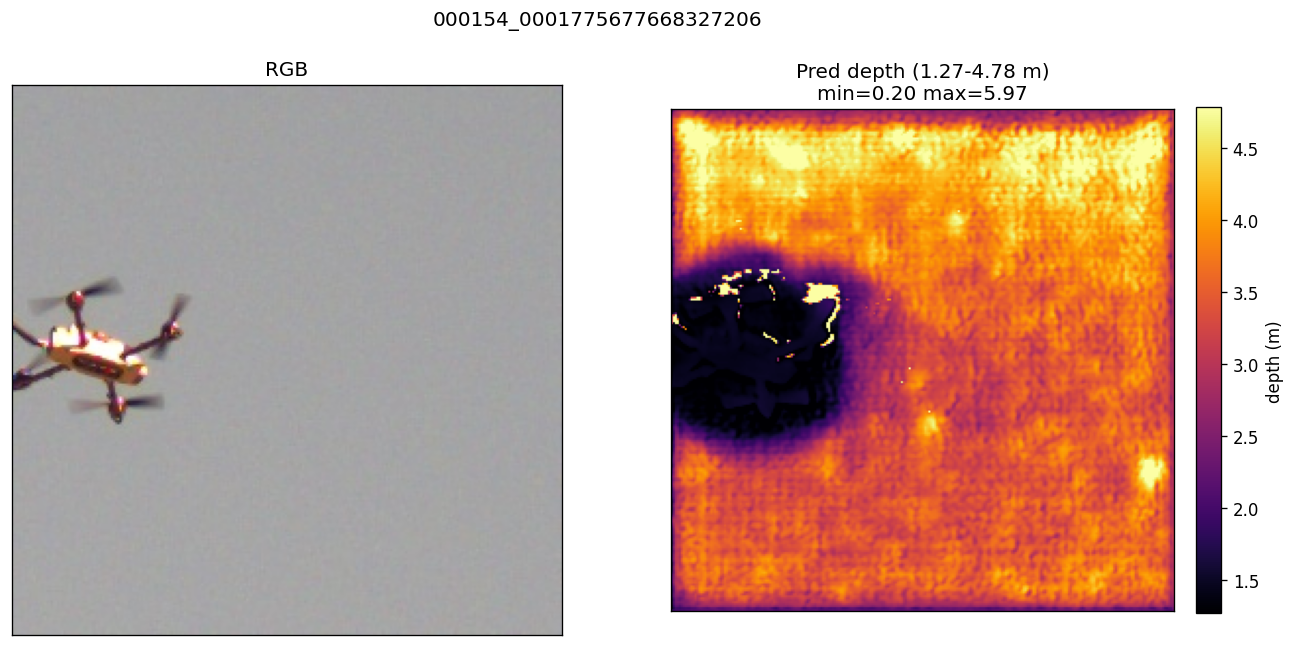

pred median (m)86.99,pred mean (m)86.27,pred range (m)15.12 → 150.04,2/98 pct (m)40.68 → 119.33


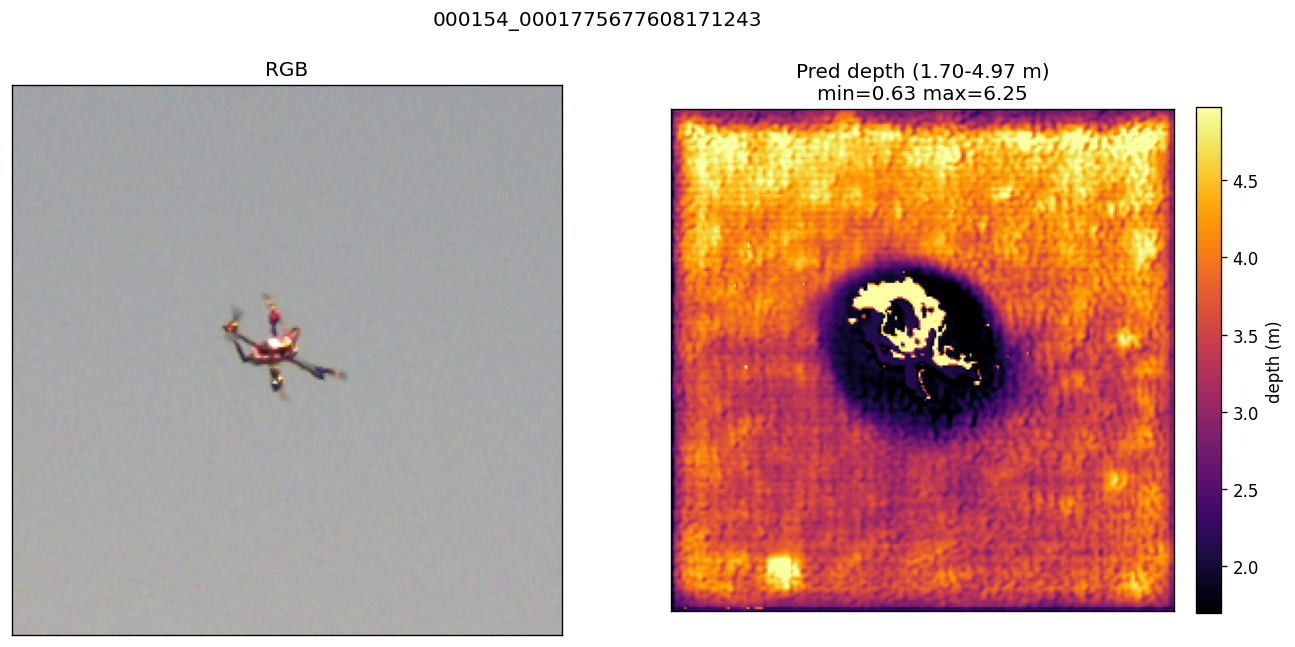

pred median (m)92.64,pred mean (m)92.05,pred range (m)28.10 → 131.98,2/98 pct (m)58.63 → 115.30


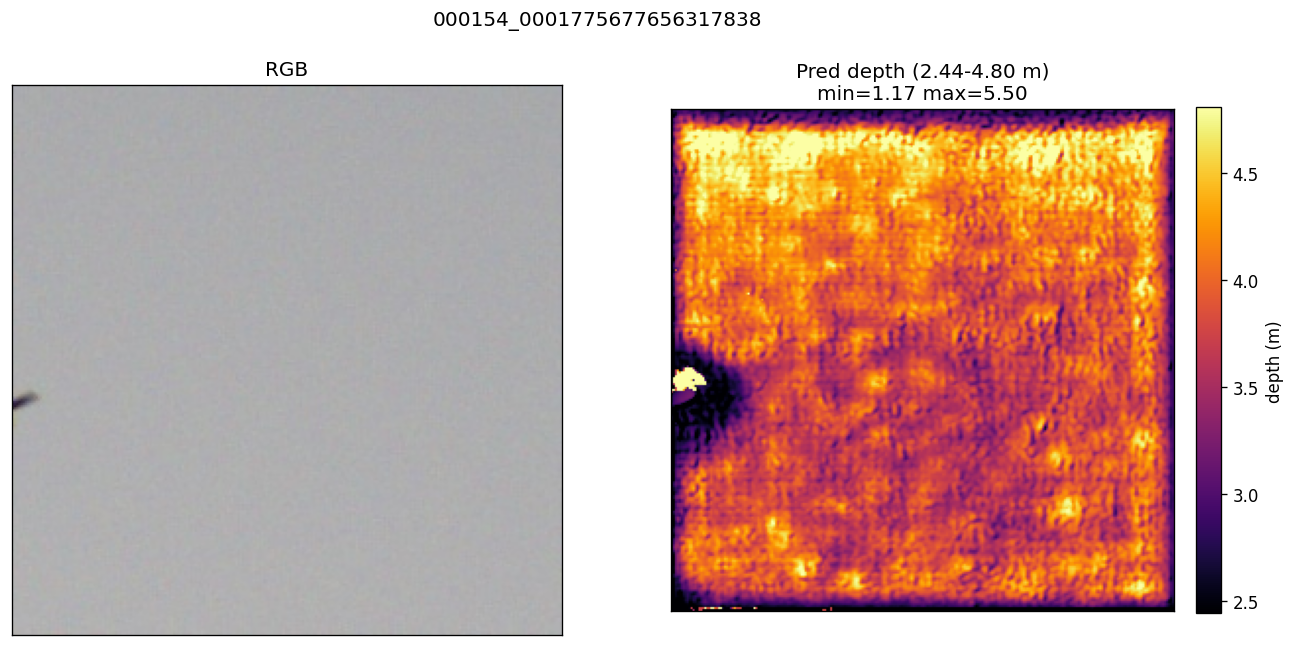

In [12]:
N_SHOW = 3
MODE = 'random'   # 'deepest' | 'shallowest' | 'random'
SEED = 1

if MODE == 'deepest':
    picks = df.sort_values('pred_median', ascending=False).head(N_SHOW)
elif MODE == 'shallowest':
    picks = df.sort_values('pred_median', ascending=True).head(N_SHOW)
elif MODE == 'random':
    picks = df.sample(n=min(N_SHOW, len(df)), random_state=SEED)
else:
    raise ValueError(MODE)

for _, row in picks.iterrows():
    stem = row['stem']
    display(HTML(f"<hr><h3 style='margin-bottom:4px'><code>{stem}</code></h3>"))
    display(HTML(
        '<table style="border:0;font-size:14px">'
        '<tr>'
        f'<td style="padding:4px 14px"><b>pred median (m)</b><br>{row["pred_median"]:.2f}</td>'
        f'<td style="padding:4px 14px"><b>pred mean (m)</b><br>{row["pred_mean"]:.2f}</td>'
        f'<td style="padding:4px 14px"><b>pred range (m)</b><br>{row["pred_min"]:.2f} &rarr; {row["pred_max"]:.2f}</td>'
        f'<td style="padding:4px 14px"><b>2/98 pct (m)</b><br>{row["pred_p2"]:.2f} &rarr; {row["pred_p98"]:.2f}</td>'
        '</tr></table>'
    ))
    display(Image(filename=str(cmp_dir / f'{stem}.png'), width=1200))

## Look up a specific image

In [ ]:
# Paste a stem (filename without extension) to inspect it.
STEM = df.iloc[0]['stem']

row = df.loc[df['stem'] == STEM].squeeze()
pred = load_pred(npy_dir / f'{STEM}.npy')

display(Markdown(
    f"### `{STEM}`\n\n"
    f"Values in real-world meters (scale x{DEPTH_SCALE:g}).\n\n"
    f"| stat | value (m) |\n"
    f"|---|---|\n"
    f"| min | **{pred.min():.3f}** |\n"
    f"| p2 | **{np.percentile(pred, 2):.3f}** |\n"
    f"| median | **{np.median(pred):.3f}** |\n"
    f"| mean | **{pred.mean():.3f}** |\n"
    f"| p98 | **{np.percentile(pred, 98):.3f}** |\n"
    f"| max | **{pred.max():.3f}** |\n"
))
display(Image(filename=str(cmp_dir / f'{STEM}.png'), width=1200))

## Depth histogram for the image above

Distribution of predicted depth across every pixel in the frame. Use this to sanity-check whether the model is confidently focused around a reasonable distance, or sprawling across an implausibly wide range.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(pred.ravel(), bins=60, color='C0', alpha=0.85)
ax.axvline(pred.mean(), color='k', linestyle='--', lw=1, label=f'mean={pred.mean():.2f} m')
ax.axvline(np.median(pred), color='C3', linestyle='--', lw=1, label=f'median={np.median(pred):.2f} m')
ax.set_title('Predicted depth over full frame')
ax.set_xlabel('depth (m)')
ax.set_ylabel('pixel count')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Dataset-wide prediction distributions

How does the model behave across the whole sample?

- **Per-image median** — typical depth predicted per frame.
- **Per-image p98** — how far the model is willing to predict.
- **Per-image range (p98 − p2)** — how much depth spread is in each frame.

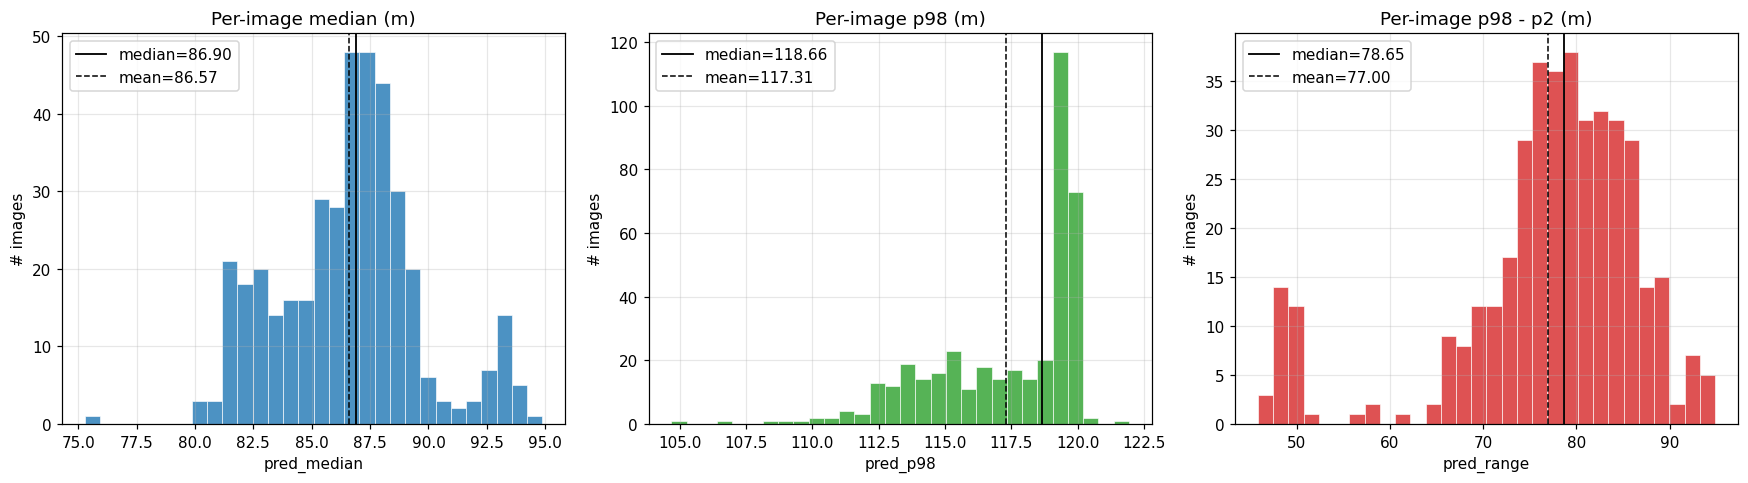

In [16]:
df = df.assign(pred_range=df['pred_p98'] - df['pred_p2'])
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, color, label in zip(
    axes,
    ['pred_median', 'pred_p98', 'pred_range'],
    ['C0', 'C2', 'C3'],
    ['Per-image median (m)', 'Per-image p98 (m)', 'Per-image p98 - p2 (m)'],
):
    vals = df[col].dropna()
    ax.hist(vals, bins=30, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(vals.median(), color='k', linestyle='-', lw=1.2, label=f'median={vals.median():.2f}')
    ax.axvline(vals.mean(), color='k', linestyle='--', lw=1.0, label=f'mean={vals.mean():.2f}')
    ax.set_title(label)
    ax.set_xlabel(col)
    ax.set_ylabel('# images')
    ax.legend()
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Compare same image across epochs

Paste a stem that's present in every epoch's `depth_npy/` to see how the model's prediction on that scene evolves during training.

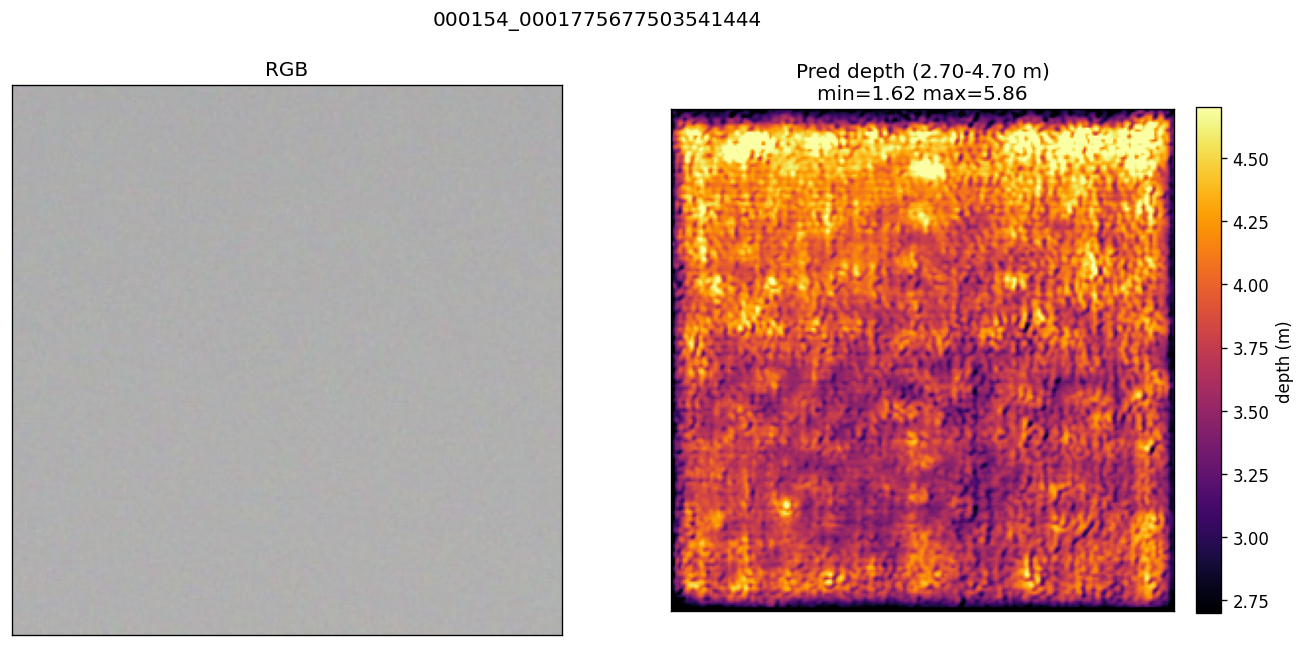

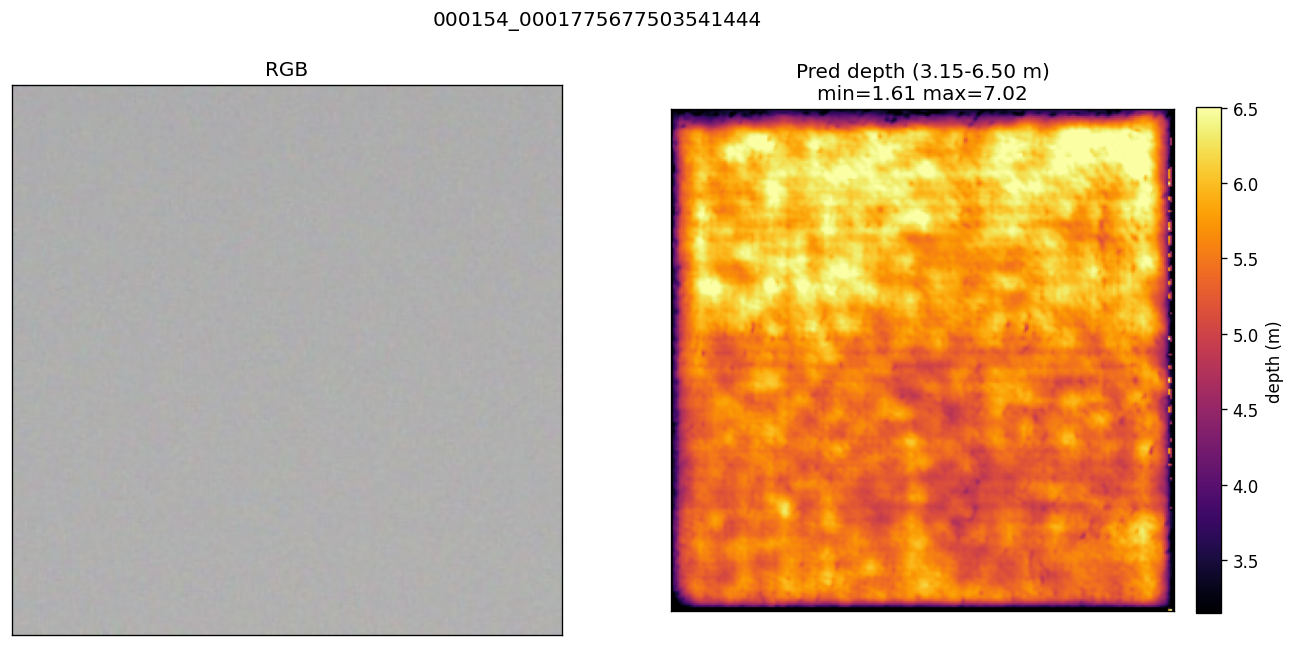

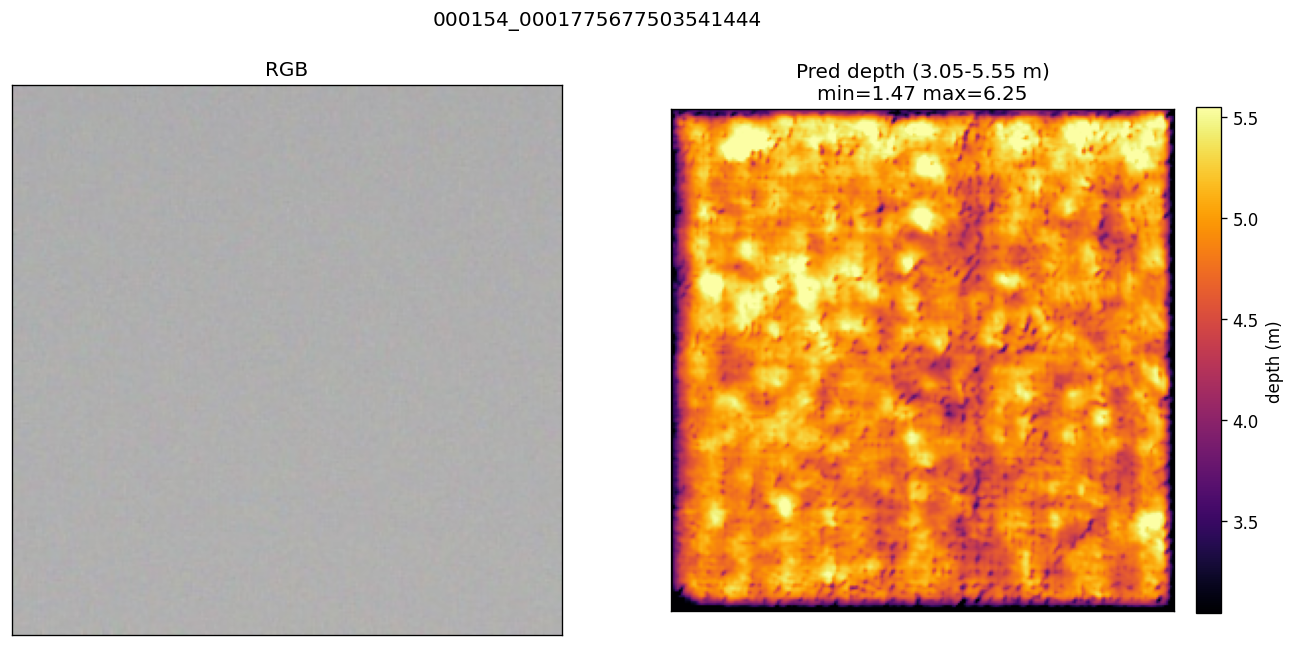

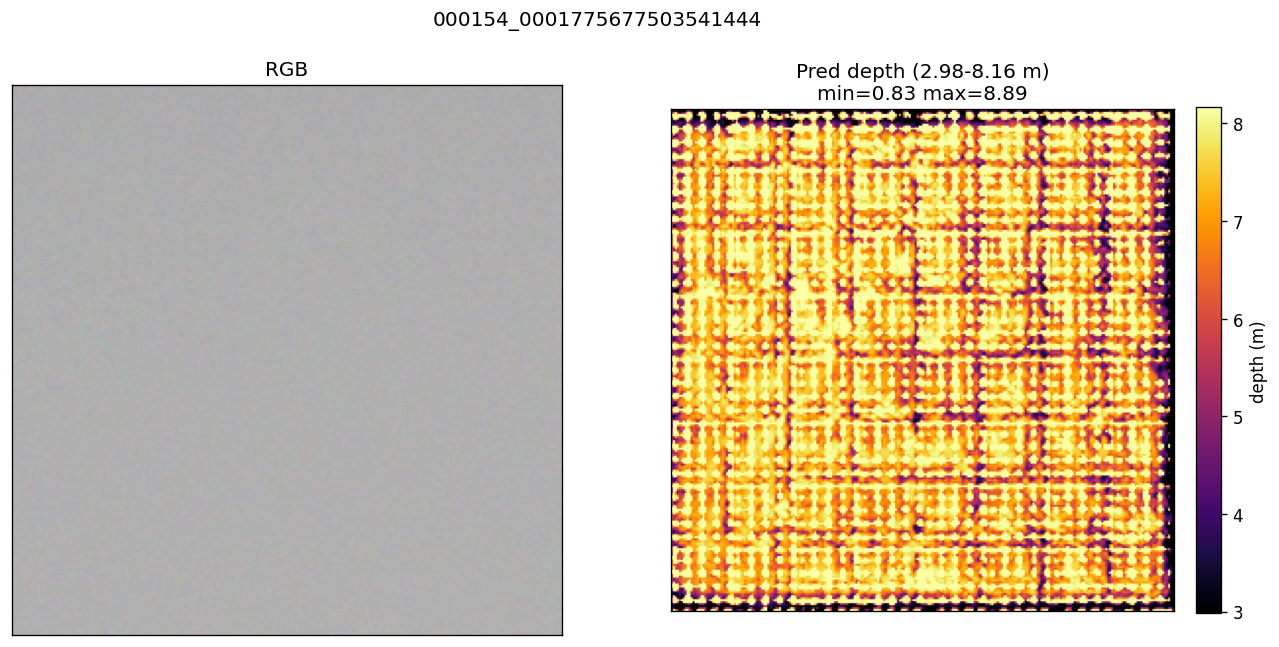

In [17]:
EPOCHS_TO_COMPARE = available  # e.g. [2, 3, 4, 19]
STEM_CMP = df.iloc[0]['stem']

missing = [e for e in EPOCHS_TO_COMPARE
           if not (RUN_DIR / f'epoch_{e:03d}' / 'comparison' / f'{STEM_CMP}.png').is_file()]
if missing:
    print(f'stem {STEM_CMP!r} missing from epochs: {missing}')

for e in EPOCHS_TO_COMPARE:
    p = RUN_DIR / f'epoch_{e:03d}' / 'comparison' / f'{STEM_CMP}.png'
    if not p.is_file():
        continue
    pred_e = load_pred(RUN_DIR / f'epoch_{e:03d}' / 'depth_npy' / f'{STEM_CMP}.npy')
    display(HTML(
        f'<hr><h4 style="margin-bottom:2px">epoch {e:03d} &mdash; '
        f'median={np.median(pred_e):.2f} m  mean={pred_e.mean():.2f} m  '
        f'range={pred_e.min():.2f}&rarr;{pred_e.max():.2f} m</h4>'
    ))
    display(Image(filename=str(p), width=1200))

## Interactive hover: click-or-hover to read depth at a pixel

Renders the RGB input side-by-side with the predicted depth map as a Plotly figure. Hover anywhere to see `(x, y, depth_m)` in the tooltip. Works on a remote VM via VS Code Remote-SSH or a port-forwarded Jupyter (`ssh -L 8888:localhost:8888 <vm>`).

- `STEM_INTERACTIVE` — which image to inspect.
- Depth is already rescaled by `DEPTH_SCALE` (real-world meters).
- If you want to *pin* a click instead of just hovering, scroll to the next cell.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from PIL import Image as PILImage

# Random pick: re-run the cell to shuffle. Set SEED to an int to pin,
# or set STEM_INTERACTIVE explicitly to inspect a specific stem.
SEED = None
STEM_INTERACTIVE = df.sample(n=1, random_state=SEED).iloc[0]['stem']
print(f'inspecting: {STEM_INTERACTIVE}')

pred_i = load_pred(npy_dir / f'{STEM_INTERACTIVE}.npy')
H, W = pred_i.shape

# Load RGB and resize to the depth resolution so pixel coordinates line up.
img_path = None
for ext in ('.jpg', '.jpeg', '.png'):
    p = rgb_dir / f'{STEM_INTERACTIVE}{ext}'
    if p.is_file():
        img_path = p
        break
if img_path is None:
    raise FileNotFoundError(f'no image for stem {STEM_INTERACTIVE}')
rgb_i = np.array(PILImage.open(img_path).convert('RGB').resize((W, H)))

lo = float(np.percentile(pred_i, 2))
hi = float(np.percentile(pred_i, 98))

# Fully-transparent colorscale — used to put an invisible heatmap over the RGB
# image so hover reports depth (go.Image does not interpolate customdata).
INVIS = [[0, 'rgba(0,0,0,0)'], [1, 'rgba(0,0,0,0)']]

fig = make_subplots(
    rows=1, cols=2, horizontal_spacing=0.06,
    subplot_titles=(f'RGB  ({W}x{H})',
                    f'Pred depth  ({lo:.1f}-{hi:.1f} m, scaled x{DEPTH_SCALE:g})'),
)

# Left column: RGB image (no hover) + invisible depth heatmap on top for hover.
fig.add_trace(go.Image(z=rgb_i, hoverinfo='skip'), row=1, col=1)
fig.add_trace(
    go.Heatmap(
        z=pred_i, colorscale=INVIS, showscale=False,
        hovertemplate='x=%{x}  y=%{y}<br>depth=%{z:.2f} m<extra>RGB</extra>',
    ),
    row=1, col=1,
)

# Right column: visible depth heatmap.
fig.add_trace(
    go.Heatmap(
        z=pred_i, zmin=lo, zmax=hi,
        colorscale='Inferno',
        colorbar=dict(title='depth (m)', x=1.02),
        hovertemplate='x=%{x}  y=%{y}<br>depth=%{z:.2f} m<extra>Pred</extra>',
    ),
    row=1, col=2,
)

# Image-coordinate convention: y increases downward, both axes locked to px.
for col in (1, 2):
    fig.update_xaxes(range=[0, W], constrain='domain', row=1, col=col, title='x (px)')
    fig.update_yaxes(range=[H, 0], scaleanchor=f'x{"" if col == 1 else "2"}',
                     scaleratio=1, row=1, col=col, title='y (px)')

fig.update_layout(
    title=f'{STEM_INTERACTIVE}  |  median={np.median(pred_i):.2f} m',
    height=520, width=1200, margin=dict(t=60, l=40, r=40, b=40),
)
fig.show()

### Pinnable click: accumulate a list of probed points

This uses `FigureWidget.on_click`. Every click on the heatmap appends a row to `clicks_df` and drops a marker on the figure. Useful for measuring a handful of specific locations (e.g. same object across frames). Works in Jupyter Lab/Notebook and in VS Code's notebook UI when `ipywidgets` is installed.

In [ ]:
widget = go.FigureWidget(
    data=[
        go.Heatmap(
            z=pred_i, zmin=lo, zmax=hi,
            colorscale='Inferno',
            colorbar=dict(title='depth (m)'),
            hovertemplate='x=%{x}  y=%{y}<br>depth=%{z:.2f} m<extra></extra>',
        ),
        go.Scatter(
            x=[], y=[], mode='markers+text',
            marker=dict(color='cyan', size=12, line=dict(color='black', width=1)),
            text=[], textposition='top right', textfont=dict(color='cyan', size=11),
            hoverinfo='skip', showlegend=False,
        ),
    ],
    layout=dict(
        title=f'click to pin &mdash; {STEM_INTERACTIVE}',
        height=620, width=900, margin=dict(t=50, l=40, r=40, b=40),
        xaxis=dict(title='x (px)', range=[0, W], constrain='domain'),
        yaxis=dict(title='y (px)', range=[H, 0], scaleanchor='x', scaleratio=1),
    ),
)

clicks = []
clicks_df = pd.DataFrame(columns=['x', 'y', 'depth_m'])

def _on_click(trace, points, state):
    global clicks_df
    if not points.xs:
        return
    for x, y in zip(points.xs, points.ys):
        xi = int(round(float(x)))
        yi = int(round(float(y)))
        xi = max(0, min(W - 1, xi))
        yi = max(0, min(H - 1, yi))
        d = float(pred_i[yi, xi])
        clicks.append({'x': xi, 'y': yi, 'depth_m': d})
    clicks_df = pd.DataFrame(clicks)
    scatter = widget.data[1]
    with widget.batch_update():
        scatter.x = clicks_df['x'].tolist()
        scatter.y = clicks_df['y'].tolist()
        scatter.text = [f"{d:.1f} m" for d in clicks_df['depth_m']]

widget.data[0].on_click(_on_click)

# Run this cell, then click on the heatmap. After clicking, evaluate `clicks_df`
# in the next cell (or re-run this one) to see the accumulated probe points.
widget

In [ ]:
# Click log. Re-run after clicking on the heatmap above.
clicks_df